Explained Variance Ratio: [0.86423964 0.12914239]
Total Variance: 0.9933820294975793


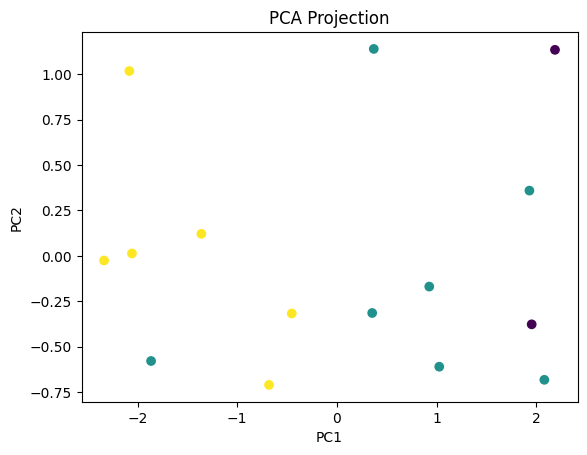

In [1]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("fitness_data.csv")

# Create target (based on WorkoutHours)
df["FitnessClass"] = np.select(
    [df["WorkoutHours"] < 3,
     (df["WorkoutHours"] >= 3) & (df["WorkoutHours"] < 6),
     df["WorkoutHours"] >= 6],
    [0, 1, 2]
)

# Features
X = df[["Age","Height","Weight"]]

# Scale
X_scaled = StandardScaler().fit_transform(X)

# PCA (2 components)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Output
print("Explained Variance Ratio:", pca.explained_variance_ratio_)
print("Total Variance:", np.sum(pca.explained_variance_ratio_))

# Plot
plt.scatter(X_pca[:,0], X_pca[:,1], c=df["FitnessClass"])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection")
plt.show()